Will Betts Cope | 11.22.23
## # CRIM Intervals:  Melodic and Harmonic

### Basic Goals

- Examine Macro-level aspects of your Mass+Model corpus (with similarity Matrices and Cadence Maps)
- Examine Micro-level aspects of your Mass+Model corpus (exploring particular ngrams, presentation types, and cadences made evident at the macro-level)
- Draw some conclusions about the overall points of similarity and difference among some subset of your pieces

### Tasks in Detail  

### 1. Exploring Entry Melodies
- 1.1 **Load the piece(s)** from your corpus

#### Shared Entries (Macro Level)

- 1.2 use the **piece.modelFinder** method to build a table summarizing the percentage of "entries" shared among the pieces.  These "entries" are soggetti (expressed as melodic ngrams) that begin after a rest or a section break.  They are thus the most likely soggetti to be remembered and the most likely to be used in important presentation types.
- 1.3 The **heatmap of the modelFinder** results will show the relatedness clearly for your corpus.
- 1.4 Which **mass movements** are most similar to the model?  To each other?

#### Shared Modules (Macro Level)

- 1.5 Now use **piece.moduleFinder** to build a table summarizing the percentage of "contrapuntal modules" shared in your corpus. These modules are also the ones that occur around the entries found in the previous step.
- 1.6 Use the **heatmap of the moduleFinder** results to compare the relatedness in your corpus.
- 1.7 How do these two calculations compare across the corpus at a macro level?  Which pieces seem to use similar melodies in the same ways?  In different ways?

#### Shared Entries (Micro Level)
- 1.8 Which **specific entry melodies** are shared by the to most similar pieces?  The list will give you an idea of which melodies are involved.
- 1.9 Make a **HeatMap of the ngrams** in your pieces, and find your shared ngrams on them.
- 1.10 Based on the visual blocks of the HeatMap (and the offsets that show when you hover on them):
    - Where in your piece do these entries appear--at the outset, middle, near the end? 
    - Are they in roughly the same place in the two related movements/pieces?
    - What Presentation Types do these shared entries seem to be involved in?  PEN?  ID?  Fuga? 
- 1.11 Now return to the **Presentation Type** method (**piece.presentationTypes**) and see what the CRIM intervals says about your pair of pieces and the partcular ngrams/entries you are focusing on.
    - What types did it find?  Do you agree?  
    - If you search for Hidden Types, does it find still others?
    - Given that the composer of the Mass is definitely using soggetti from the Model, did they do the _same_ thing with that material as found in the model?  Or something different?  Do you they think they were being creative, or just going through the motions?
    - If you listen to the piece, do any of the machine patterns make sense to you?
    
### 2. Shared Cadences

- 2.1 About Cadence Methods

#### Shared Cadences (Macro Level)
- 2.2 Radar Plot the Cadences for Your Corpus (and compare)
- 2.3 Summary of Cadences by Tone and Type across your Corpus
--  For reference, this table might help you be more specific about the differences and simliarities among the pieces and the types of cadences they share.
-- Consider each in turn and think about what makes your pieces **similar** or **different**.
- 2.4. Your Commentary on the previous steps

- 2.5  Tablular Summary of the Cadences in your Corpus
- 2.6  Finding Last Lowest Tone of each Piece

#### Shared Cadences (Micro Level)
- 2.7  Plotting the Cadences in each piece as a Series
- 2.8  Finding Substrings of similar Cadences
- 2.9 ==> Your Commentary on the Cadence Tables and Charts
    
    
### 3.  Overall Conclusions

- How are your chosen pieces most related?  Most different?  Write a few sentences and provide some highlights from your analysis



#### Read Documentation for Each Method
- Read the documentation with this command `print(ImportedPiece.YourMethod.__doc__)`, where you will replace `'YourMethod'` with the name of the individual method, for example `print(ImportedPiece.melodic.__doc__)`


*** 

### A. Import Intervals and Other Code


In [1]:
import crim_intervals
from crim_intervals import * 
from crim_intervals import main_objs
from os import listdir
import os.path
import crim_intervals.visualizations as viz
import pandas as pd
import re
import altair as alt
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact
from IPython.display import display
import requests
import os
import glob
import plotly.graph_objects as go
from os import listdir
import os.path

# keep these functions

def convertTuple(tup):
    out = ""
    if isinstance(tup, tuple):
        out = ', '.join(tup)
    return out

def _offset_joiner(a):
        b = ', '.join(map(str, a))
        return b

MYDIR = ("saved_csv")
CHECK_FOLDER = os.path.isdir(MYDIR)

# If folder doesn't exist, then create it.
if not CHECK_FOLDER:
    os.makedirs(MYDIR)
    print("created folder : ", MYDIR)
else:
    print(MYDIR, "folder already exists.")
    
MUSDIR = ("Music_Files")
CHECK_FOLDER = os.path.isdir(MUSDIR)

# If folder doesn't exist, then create it.
if not CHECK_FOLDER:
    os.makedirs(MUSDIR)
    print("created folder : ", MUSDIR)
else:
    print(MUSDIR, "folder already exists.")

saved_csv folder already exists.
Music_Files folder already exists.


## B. Importing a Piece

* Choose ONE of the following!

### Importing Just One Model

In [2]:
# Import your Model

prefix = 'https://crimproject.org/mei/CRIM_Model_'

model_ID = '0047' # <== put your ID number here!

# join the strings and import piece
url = prefix + model_ID + '.mei'
piece = importScore(url)

print(piece.metadata)


{'title': 'Nigra sum', 'composer': 'Jean Lhertier', 'date': 1532}


### Importing One Full Mass

In [3]:
# Import Your Mass as a corpus
corpus = []
mass_id = "0036" # <== put your Mass number here!
for l in range(1, 6):
    mass = f'https://crimproject.org/mei/CRIM_Mass_{mass_id}_{l:01}.mei'
    corpus.append(importScore(mass))

### Import Model and Mass as a Combined Corpus

In [4]:
# Import Your Mass and Model as a combined Corpus:
corpus_list = []
prefix = 'https://crimproject.org/mei/CRIM_Model_'

# select IDs for your Mass and Model
model_id = "0047"  # <==  put your model number here!
mass_id = "0036" # <== put your Mass number here!
model = prefix + model_id + '.mei'
corpus_list.append(model)
for l in range(1, 6):
    mass = f'https://crimproject.org/mei/CRIM_Mass_{mass_id}_{l:01}.mei'
    corpus_list.append(mass)
corpus_list

['https://crimproject.org/mei/CRIM_Model_0047.mei',
 'https://crimproject.org/mei/CRIM_Mass_0036_1.mei',
 'https://crimproject.org/mei/CRIM_Mass_0036_2.mei',
 'https://crimproject.org/mei/CRIM_Mass_0036_3.mei',
 'https://crimproject.org/mei/CRIM_Mass_0036_4.mei',
 'https://crimproject.org/mei/CRIM_Mass_0036_5.mei']

In [5]:
corpus = CorpusBase(corpus_list)

# Shared Entries (Macro Level)



### 1.1 Melodic Entries as Similarity Matrix

* Use the **modelFinder** method to build a table summarizing the percentage of "entries" shared among the pieces. 
* These "entries" are soggetti (expressed as melodic ngrams) that begin after a rest or a section break.  They are thus the most likely soggetti to be remembered and the most likely to be used in important presentation types.
* This method returns a "driving distance table" showing how likely each model was a source for each mass. This
is represented by a score 0-1 where 0 means that this relationship was highly unlikely
and 1 means that the the two are highly likely to be related in this way (or that a
piece was compared to itself). Specifically, **the value is the percentage of each piece's
thematic (i.e. recurring) melodies can be found as thematic melodies in all the other pieces in your corpus**. The
specific number of times they appear in the model is not considered, provided that it is
at least two.


### How to Read the Results:

* As you read across, you will see the percentage of melodies in the row value that come from the corresponding column value.  

### Provide Your Commentary as indicated


In [6]:
corpus = CorpusBase(corpus_list)
similarity_matrix = corpus.modelFinder()
similarity_matrix

Model,CRIM_Model_0047,CRIM_Mass_0036_1,CRIM_Mass_0036_2,CRIM_Mass_0036_3,CRIM_Mass_0036_4,CRIM_Mass_0036_5
Mass,,,,,,
CRIM_Model_0047,1.000000,0.374449,0.572687,0.709251,0.475771,0.506608
CRIM_Mass_0036_1,0.471545,1.000000,0.817073,0.715447,0.479675,0.430894
CRIM_Mass_0036_2,0.436490,0.602771,1.000000,0.727483,0.468822,0.448037
CRIM_Mass_0036_3,0.499287,0.422254,0.621969,1.000000,0.386591,0.413695
CRIM_Mass_0036_4,0.467980,0.389163,0.640394,0.610837,1.000000,0.379310
CRIM_Mass_0036_5,0.646091,0.460905,0.757202,0.703704,0.456790,1.000000


###  1.2 The Melodic Matrix as Heatmap

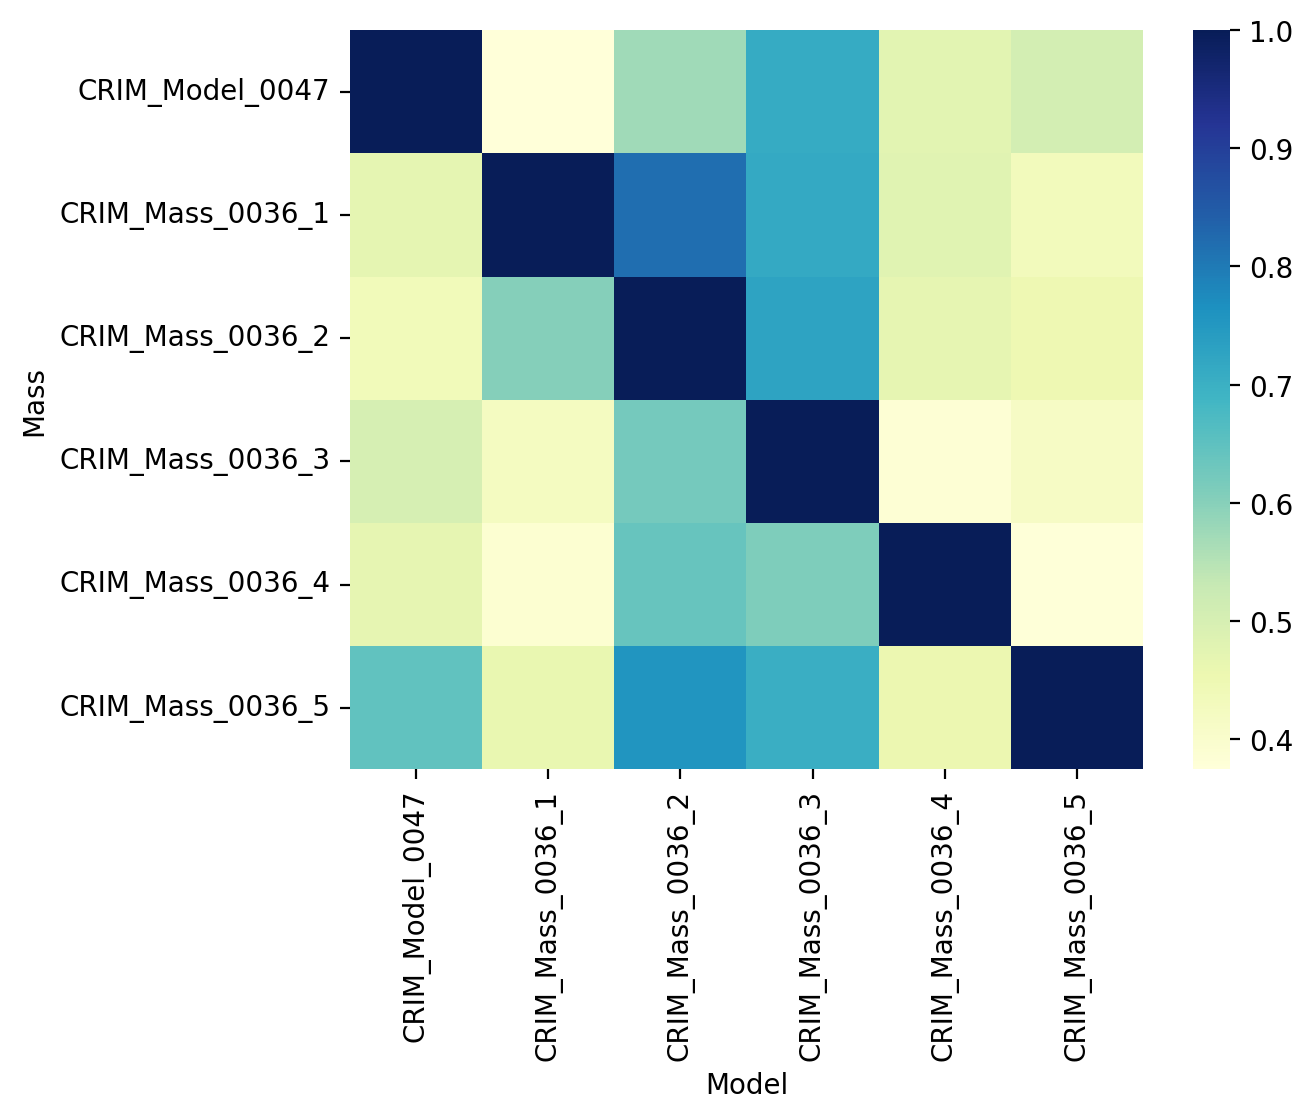

In [7]:
# melodic matrix
dataplot = sns.heatmap(similarity_matrix, cmap="YlGnBu", annot=False)
plt.show()


In [8]:
model_list = ['https://crimproject.org/mei/CRIM_Model_0047.mei']
mass_list = ['https://crimproject.org/mei/CRIM_Mass_0036_1.mei',
             'https://crimproject.org/mei/CRIM_Mass_0036_2.mei',
              'https://crimproject.org/mei/CRIM_Mass_0036_3.mei',
                'https://crimproject.org/mei/CRIM_Mass_0036_4.mei',
            'https://crimproject.org/mei/CRIM_Mass_0036_5.mei']

Issue: the information in the table below was not consistent with the first matrix

Solution: change the model and mass numbers above to the correct pieces

In [9]:
mod_corp = CorpusBase(model_list)
mass_corp = CorpusBase(mass_list)
cross_plot = mod_corp.modelFinder(masses=mass_corp, models=mod_corp)
cross_plot

Model,CRIM_Model_0047
Mass,
CRIM_Mass_0036_1,0.471545
CRIM_Mass_0036_2,0.436490
CRIM_Mass_0036_3,0.499287
CRIM_Mass_0036_4,0.467980
CRIM_Mass_0036_5,0.646091


## ==> 1.4 Put your commentary on the shared entries matrix below

* Which pieces in your set seem to be most closely related in terms of melodic entries?  Which ones are not?  Which movements of the Mass seem to share the most entries with each other?

It appears that mass five is the most related to the model, since ~65% of its melodies come from the mass, while he others do not break 50% similarity. Mass 2 shares the fewest melodies with the model at ~44%; however, all of the first four masses are in a similar range of 44%-50% similirity with the model, there is not one outlier. 
Interestingly, when comparing in the opposite direction (% of model melodies that come from each mass) the results are different. In this comparison, mass 3 shares the most with the model, with ~71% of the model's melodies coming from it. This difference initially seemed strange to me, but after further thought it makes sense that comparing in the opposite direction would not produce the same result.

Between the masses, number 2 has the 2 highest percentages borrowed from it, as mass 2 borrowed ~82% of its melodies, and mass 5 borrowd ~76%; however, it appears that mass 3 was the piece most consistenly referenced by others, since every piece but 4 used at least 70% of the melodies from mass 3.

# Shared Modules (Macro Level)

### 1.5 Contrapuntal (Modular) Ngrams as Similarity Matrix

* **Contrapuntal Modules** are 'ngrams' that represent the motion of a pair of voices.  The tool finds the patterns between every pair of voices, then filters these to correspond to the moments of the 'entries'.  So it tells us not only that there are shared melodies, but what is happening to the melodies in their contrapuntal context.
* `moduleFinder`  method identifies all of the `modular ngrams` in each piece that **coincide with the melodic entries**.  These are the modules found in _all_ voices around the moment of the given melodic entry, so they will
include both the entries and other soggetti, too.

* Lists of unique modular ngrams are then compared across the corpus, resulting in a matrix of values.
* This method returns a "driving distance table" showing how likely each model was a source for each mass. This
is represented by a score 0-1 where 0 means that this relationship was highly unlikely
and 1 means that the the two are highly likely to be related in this way (or that a
piece was compared to itself). Specifically, **the value is the percentage of each piece's
modular ngrams (the ones that occur at the moment of the entries) can be found in each of the other pieces in the corpus.**

#### How to Read the Results:
    - As you read across, you will see the percentage of modular ngrams in the row value that come from the corresponding column value.  

In [10]:
corpus = CorpusBase(corpus_list)
module_matrix = corpus.moduleFinder()
module_matrix

Model,CRIM_Model_0047,CRIM_Mass_0036_1,CRIM_Mass_0036_2,CRIM_Mass_0036_3,CRIM_Mass_0036_4,CRIM_Mass_0036_5
Mass,,,,,,
CRIM_Model_0047,1.000000,0.285149,0.346535,0.283168,0.312871,0.304950
CRIM_Mass_0036_1,0.294521,1.000000,0.344749,0.335616,0.319635,0.335616
CRIM_Mass_0036_2,0.310510,0.315287,1.000000,0.364650,0.321656,0.329618
CRIM_Mass_0036_3,0.316751,0.336041,0.384772,1.000000,0.329949,0.347208
CRIM_Mass_0036_4,0.395564,0.397412,0.439926,0.402957,1.000000,0.388170
CRIM_Mass_0036_5,0.362500,0.397500,0.427500,0.387500,0.357500,1.000000


### 1.6 Module Matrix as Heatmap

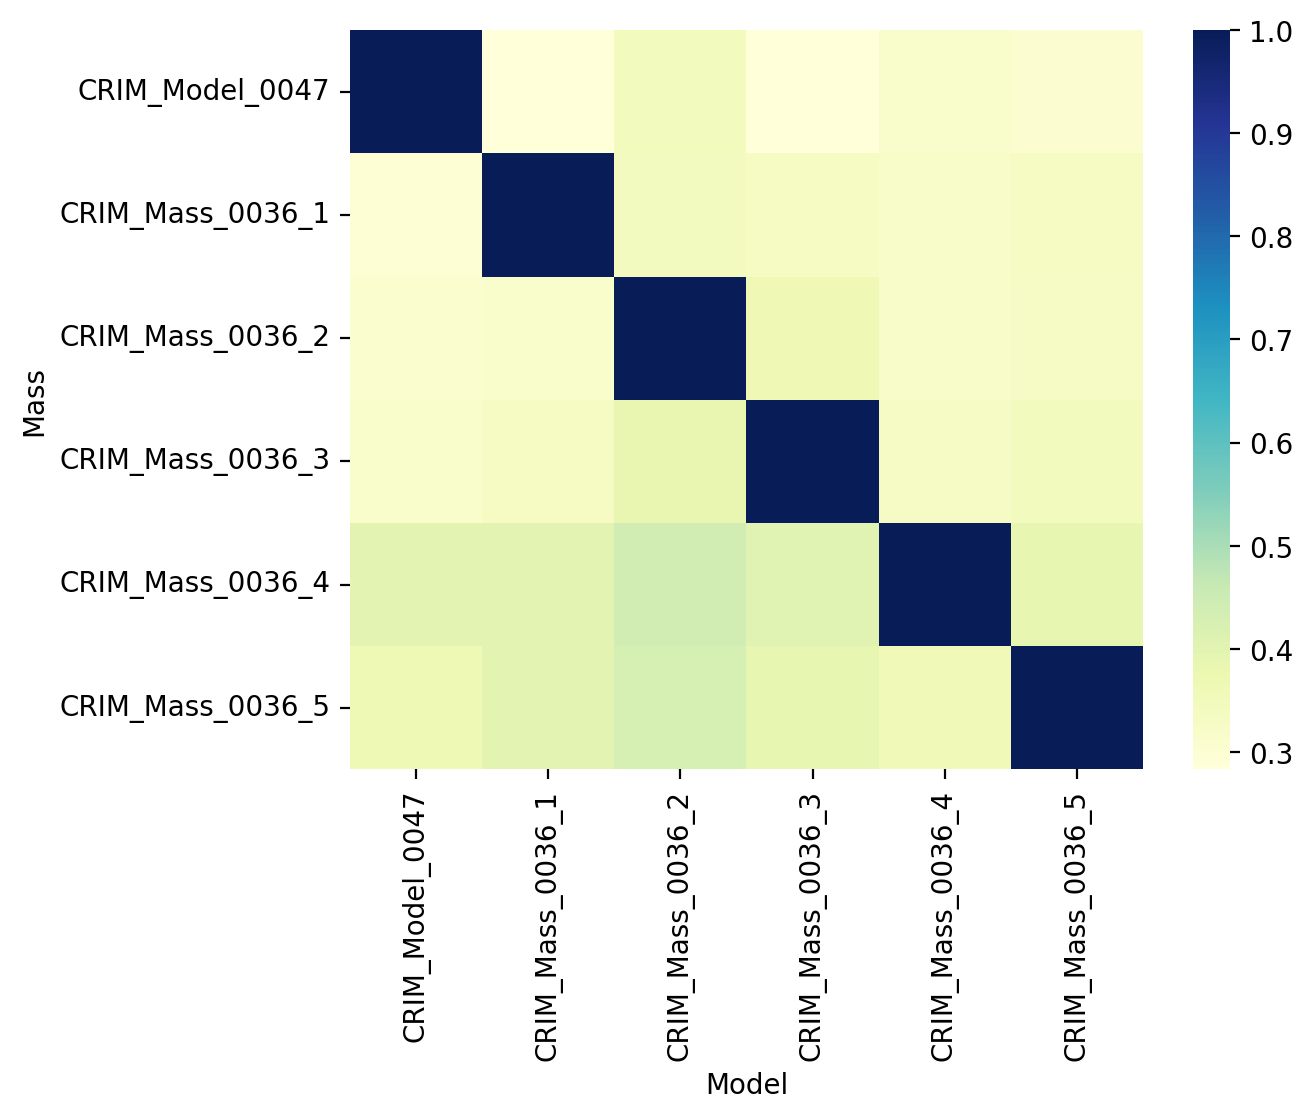

In [11]:
# module matrix

dataplot = sns.heatmap(module_matrix, cmap="YlGnBu", annot=False)
plt.show()

In [12]:
similarity_matrix.compare(module_matrix).round(2)

Model            CRIM_Model_0047       CRIM_Mass_0036_1        \
                            self other             self other   
Mass                                                            
CRIM_Model_0047              NaN   NaN             0.37  0.29   
CRIM_Mass_0036_1            0.47  0.29              NaN   NaN   
CRIM_Mass_0036_2            0.44  0.31             0.60  0.32   
CRIM_Mass_0036_3            0.50  0.32             0.42  0.34   
CRIM_Mass_0036_4            0.47  0.40             0.39  0.40   
CRIM_Mass_0036_5            0.65  0.36             0.46  0.40   

Model            CRIM_Mass_0036_2       CRIM_Mass_0036_3        \
                             self other             self other   
Mass                                                             
CRIM_Model_0047              0.57  0.35             0.71  0.28   
CRIM_Mass_0036_1             0.82  0.34             0.72  0.34   
CRIM_Mass_0036_2              NaN   NaN             0.73  0.36   
CRIM_Mass_0036_3             0.62  0.38              NaN   NaN   
CRIM_Mass_0036_4             0.64  0.44             0.61  0.40   
CRIM_Mass_0036_5             0.76  0.43             0.70  0.39   

Model            CRIM_Mass_0036_4       CRIM_Mass_0036_5        
                             self other             self other  
Mass                                                            
CRIM_Model_0047              0.48  0.31             0.51  0.30  
CRIM_Mass_0036_1             0.48  0.32             0.43  0.34  
CRIM_Mass_0036_2             0.47  0.32             0.45  0.33  
CRIM_Mass_0036_3             0.39  0.33             0.41  0.35  
CRIM_Mass_0036_4              NaN   NaN             0.38  0.39  
CRIM_Mass_0036_5             0.46  0.36              NaN   NaN

## ==>  Put your commentary on the shared modules matrix below

* Which pieces in your set seem to be most closely related in terms of modular entries?  Which ones are not?  Which movements of the Mass seem to share the most modular with each other?

When comparing the model and masses using Contrapuntal Ngrams, the correlations look much weaker. Mass 4 now appears to have borrowed the most from the model with ~40%, and mass 1 the least with ~29, with the other masses in the low to mid 30s. Mass 2 still has the highest percentage borrowed from it, but this time it is mass 4 that borrowed the most, at ~44%. 


# Shared Entries (Micro Level)

#### Here we explore _where_ and _how_ the shared melodies are presented in each piece

* Load a specific pair of closely related pieces from your corpus - model and mass 5
* Find exactly which melodic entries are shared
* Find out *where* these melodies occur in each piece
* Check the Fuga, PEN, and ID Presentation Types to see how the melodies are treated in each piece.  Pick one or two melodies (and Presentation Types) as examples to describe.


In [13]:
# Specify the Model
model = corpus_list[0] # <== the model will be score "0"
model = importScore(model)

# Specify the Mass Movement(s)
mass_movement = corpus_list[5] # <== select the index number of your mass from the corpus.  "1" is the Kyrie, "5" is the Agnus
mass_movement = importScore(mass_movement)
print(model.metadata, mass_movement.metadata)

{'title': 'Nigra sum', 'composer': 'Jean Lhertier', 'date': 1532} {'title': 'Missa Nigra sum: Agnus dei', 'composer': 'Giovanni Pierluigi da Palestrina', 'date': 1590}


### Get the Entries and Detailed Index for A Pair of Pieces

In [14]:
# for the model
model_entries = model.entries(thematic=True, anywhere=True, n=4)
# model_entries = model_entries.applymap(convertTuple)
model_entries_det = model.detailIndex(model_entries, offset=True, progress=True)

# for the mass movement
mass_movement_entries = mass_movement.entries(thematic=True, anywhere=True, n=4)
# mass_movement_entries = mass_movement_entries.applymap(convertTuple)
mass_movement_entries_det = mass_movement.detailIndex(mass_movement_entries, offset=True, progress=True)

# check the detailed view as needed for each
# model_entries_det
# mass_movement_entries_det

### 1.8 Find the nGrams shared by your pieces

In [15]:

model_entries = model.entries(thematic=True, anywhere=True, n=4)
model_entries_stack = model_entries.stack()
mass_movement_entries = mass_movement.entries(thematic=True, anywhere=True, n=4)
mass_movement_entries_stack = mass_movement_entries.stack()
shared_entries = list(set(mass_movement_entries_stack).intersection(model_entries_stack))
shared_entries = shared_entries[1:]
shared_entries


[('-2', '-2', '-2', '-2'),
 ('-2', '-3', '2', '2'),
 ('-2', '-4', '3', '2'),
 ('4', '-2', '2', '-2'),
 ('2', '-3', '3', '-2'),
 ('2', '2', '-3', '2'),
 ('2', '2', '-2', '-2'),
 ('5', '-5', '5', '-2'),
 ('2', '-3', '2', '2')]

### 1.9 Make a Heatmap of Shared Entries in Two Pieces

* Let's look at **where** the shared melodies appear in each of your pieces.

* Judging only from the visualization, where do the shared melodies appear, and how similar does the treatment of them seem to be?

#### Note that you can also decide to compare one MASS movement with another MASS movement!


### Model Heatmap

In [16]:
## Use this for the Model Heatmap

nr = model.notes(combineUnisons=True) 
mel = model.melodic(df=nr, kind='d', compound=True, unit=0, end=False)
mel_ngrams = model.ngrams(df=mel, n=4)
entry_ngrams = model.entries(df=mel, n=4)
mel_ngrams_duration = model.durations(df=mel, n=4, mask_df=entry_ngrams)
viz.plot_ngrams_heatmap(entry_ngrams, mel_ngrams_duration, selected_patterns=shared_entries, voices=[])


alt.Chart(...)

### Mass Movement Heatmap

In [17]:
## Use this for the Mass Movement Heatmap

nr = mass_movement.notes(combineUnisons=True) 
mel = mass_movement.melodic(df=nr, kind='d', compound=True, unit=0, end=False)
mel_ngrams = mass_movement.ngrams(df=mel, n=4)
entry_ngrams = mass_movement.entries(df=mel, n=4)
mel_ngrams_duration = mass_movement.durations(df=mel, n=4, mask_df=entry_ngrams)
viz.plot_ngrams_heatmap(entry_ngrams, mel_ngrams_duration, selected_patterns=shared_entries, voices=[])

alt.Chart(...)

## ==> 1.10 Your Commentary about the Heatmaps

* Based on what you can see, **what do the composers seem to be doing with the shared melodies**?  
* Do the composers use **certain melodies in the same approximate position**?  
* Do they move through these melodies in the **same order or sequence** over the course of the piece?  
* What **Presenation Types (Fuga, PEN, ID) seems to be involved**?  
* Do any melodies seem particular worth comparing in terms of their treatment in the two pieces?  

It seems like the composer of the mass adopted the melodies of the model and used them many times, even though the model composer used them more sparingly originally. The mass composer used the melodies in apporximately the same position and sequence, but the voices used were often different. Fro example, the brown melody, sung only in the bass in the model, is sung by almost all voices in the mass. The most common presentation type (all but one medoldy) seems to be fuga, with ID second (one melody), and no PEN.

#### Make the Short Lists of These Shared Ngrams and Their Offsets

In [19]:
# for the model
model_short_list = model_entries_det[model_entries_det.isin(shared_entries)].dropna(how='all').stack()
model_offsets_of_shared_entries = model_short_list.index.get_level_values(2)
model_offsets_of_shared_entries = model_offsets_of_shared_entries.unique()

# for the mass movement
mass_movement_short_list = mass_movement_entries_det[mass_movement_entries_det.isin(shared_entries)].dropna(how='all').stack()
mass_movement_offsets_of_shared_entries = mass_movement_short_list.index.get_level_values(2)
mass_movement_offsets_of_shared_entries = mass_movement_offsets_of_shared_entries.unique()


### 1.11 Get Shared Entries as Presentation Types

* Note that not all shared entries will be used as Fuga, ID, and PEN but for those that appear in a pair of pieces, it can be informative to compare **how** they are treated!



In [25]:
# here we filter the PTypes to include ONLY those found in both the model and Mass movement

# here for the model
model_p_types = model.presentationTypes(limit_to_entries = True,
                        body_flex = 0,
                        head_flex = 1,
                        include_hidden_types = False,
                        combine_unisons = True,
                       melodic_ngram_length = 4)

model_shared_entry_ptypes = model_p_types[model_p_types.First_Offset.isin(model_offsets_of_shared_entries)]
model_ptypes = model_shared_entry_ptypes.drop(columns=['Offsets', 'Flexed_Entries', "Parallel_Entries", 'Parallel_Voice', 'Count_Non_Overlaps'])

# here for the Mass movement


mass_movement_p_types = mass_movement.presentationTypes(limit_to_entries = True,
                        body_flex = 0,
                        head_flex = 1,
                        include_hidden_types = False,
                        combine_unisons = True,
                       melodic_ngram_length = 4)


mass_movement_shared_entry_ptypes = mass_movement_p_types[mass_movement_p_types.First_Offset.isin(mass_movement_offsets_of_shared_entries)]
mass_movement_ptypes = mass_movement_shared_entry_ptypes.drop(columns=['Offsets', 'Flexed_Entries', "Parallel_Entries", 'Parallel_Voice', 'Count_Non_Overlaps'])
combined_ptypes = pd.concat([model_ptypes, mass_movement_ptypes])


### 1.11 (sorted!)  Now, Sort the Results so we see the Shared Melodies Together


In [26]:
combined_ptypes.sort_values('Soggetti')

,Composer,Title,First_Offset,Measures_Beats,Melodic_Entry_Intervals,Soggetti,Time_Entry_Intervals,Voices,Presentation_Type,Number_Entries,Progress
9,Jean Lhertier,Nigra sum,594.0,"[75/2.0, 78/1.0, 80/1.0, 81/1.0]","[P4, P-4, P-5]","[(-2, -2, -2, -2)]","[22.0, 16.0, 8.0]","[Quinta, Cantus, Altus, Bassus]",FUGA,4,0.834270
9,Giovanni Pierluigi da Palestrina,Missa Nigra sum: Agnus dei,540.0,"[68/3.0, 70/1.0, 70/4.0, 73/2.0, 73/4.0, 75/1....","[P1, P-5, P8, P-5, M2, P-5, P5, M-2, P1, P-4, ...","[(-2, -2, -2, -2)]","[12.0, 6.0, 20.0, 4.0, 10.0, 4.0, 6.0, 6.0, 14...","[Tenor secundus, Altus, Bassus, Cantus, Tenor ...",FUGA,12,0.767045
1,Jean Lhertier,Nigra sum,24.0,"[4/1.0, 8/1.0]",[P-8],"[(-2, -3, 2, 2)]",[32.0],"[Cantus, Altus]",FUGA,2,0.033708
0,Giovanni Pierluigi da Palestrina,Missa Nigra sum: Agnus dei,0.0,"[1/1.0, 4/1.0, 6/3.0, 9/3.0]","[P8, P4, P-8]","[(-2, -4, 3, 2)]","[24.0, 20.0, 24.0]","[Bassus, Altus, Cantus, Tenor secundus]",ID,4,0.000000
2,Jean Lhertier,Nigra sum,114.0,"[15/2.0, 15/4.0, 17/4.0, 20/2.0, 21/3.0, 23/2.0]","[P5, P-8, P1, P-5, P12]","[(2, -3, 2, 2)]","[4.0, 16.0, 20.0, 10.0, 14.0]","[Quinta, Cantus, Altus, Tenor, Bassus, Cantus]",FUGA,6,0.160112
2,Giovanni Pierluigi da Palestrina,Missa Nigra sum: Agnus dei,122.0,"[16/2.0, 17/2.0, 18/1.0, 20/4.0, 22/4.0, 25/2.0]","[P4, P-12, P1, P5, P1]","[(2, -3, 2, 2)]","[8.0, 6.0, 22.0, 16.0, 20.0]","[Altus, Cantus, Tenor primus, Bassus, Tenor se...",FUGA,6,0.173295
7,Giovanni Pierluigi da Palestrina,Missa Nigra sum: Agnus dei,382.0,"[48/4.0, 50/4.0, 51/4.0]","[P-5, P8]","[(2, -3, 3, -2)]","[16.0, 8.0]","[Tenor primus, Tenor secundus, Altus]",FUGA,3,0.542614
3,Giovanni Pierluigi da Palestrina,Missa Nigra sum: Agnus dei,218.0,"[28/2.0, 30/4.0]",[m-6],"[(2, 2, -2, -2)]",[20.0],"[Altus, Tenor primus]",FUGA,2,0.309659
10,Giovanni Pierluigi da Palestrina,Missa Nigra sum: Agnus dei,646.0,"[81/4.0, 86/4.0]",[M2],"[(2, 2, 2, 2)]",[40.0],"[Tenor secundus, Altus]",FUGA,2,0.917614
8,Giovanni Pierluigi da Palestrina,Missa Nigra sum: Agnus dei,418.0,"[53/2.0, 54/2.0, 56/2.0, 59/2.0, 60/4.0, 62/2....","[P1, P4, P-11, P8, P4, P-8, P-4]","[(5, -5, 5, -2)]","[8.0, 16.0, 24.0, 12.0, 12.0, 16.0, 14.0]","[Tenor secundus, Altus, Cantus, Bassus, Altus,...",FUGA,8,0.593750


## 1.11 ==> Your Commentary on the Presentation Type Comparison

* Based on your estimation from the heatmap (above), what seems to be going on as the composer of the Mass quotes or transforms melodies from the Model?  
* Pick **two or three shared melodies** and consider how the composer of the Mass and Model have treated them.  
* What is the same or different about the **Time_Entry_Intervals** and  the **Melodic_Entry_Intervals**?  The overall predicted **Presentation_Type**?




It seems like the mass composer quotes the melodies of the model pretty faithfully, and very often. The quotes happen in roughtly the same place, and usually the same presentation. For example, the melody labled 2 in the table above is played at roughly the same time (within 10 measures), in 6 voices, and presented as a fuga. There is one melody that differs in presentation (0 in the table above), which happens near the start. In the model it appears just after the start in the qiuntus and the bassus and is presented as a fuga; however, in the mass it is the opening of the piece, and played in the Bassus, Altus, Cantus, and Tenor secundus, presented as an ID. in both melodies, the Time_Entry_Intervals and Melodic_Entry_Intervals are different between model and mass, which makes sense to me, sinc having both of those exactly the same would feel more like copying and pasting from a piece, rather than quoting it.

# 2. Exploring Cadences

### 2.1 Comparing Cadences with Radar Plots and Tables (Macro Level)

How do the cadential plans of your pieces compare?  Which pieces are similar or distinctive?

In this section you will explore the 'tonal footprint' of your pieces with the Radar Plot tool.

The tool counts and plots the number of cadences that end on a particular tone.  

It also can provide a more detailed view that counts and plots the sub-types of cadences (some are strong, others weak).


* Of course longer movements such as _Gloria_ and _Credo_ are likely to involve more cadences than short pieces.
* But do the plots for the various pieces in your corpus resemble each other in overvall shape?
* Are there any outliers?
* What are the two or three main *tones* used in the cadences?

Options:
```
corpus.compareCadenceRadarPlots(combinedType=False, displayAll=True)
```


### 2.2 Radar Plot the Cadences for Your Corpus

You have various choices: 

* ```combinedType=False``` is relatively simple--just the **final tone** of each cadence in each piece
* ```combinedType=True``` gives the **final tone and the special type** of the cadence (evaded or otherwise modified)
* ```displayAll=True``` shows the cadences against a range of all possible cadences, with "D" at the top, then moving ahead by fifth (to A, E, etc)
* ```displayAll=False``` shows only the cadence tones that appear in these pieces
* It is also possible to limit the display to cadences involving on a specific number of voices:  ```sounding=3```

In [33]:
corpus.compareCadenceRadarPlots(combinedType=False, displayAll=False, renderer='iframe')

### 2.3  Summary of Cadences by Tone and Type across your Corpus

* For reference, this table might help you be more specific about the differences and simliarities among the pieces and the types of cadences they share.


In [28]:
func = ImportedPiece.cadences
list_of_dfs = corpus.batch(func=func, kwargs={'keep_keys': True}, metadata=True)
combined_df = pd.concat(list_of_dfs, ignore_index=False)
col_list = ['Composer', 'Title', 'Measure', 'Beat', 'CadType', 'Tone', 'Progress']
combined_df = combined_df[col_list]
grouped_types = combined_df.groupby(['Tone', 'CadType', 'Composer', 'Title']).size().reset_index(name='counts')
grouped_types.head(13)


,Tone,CadType,Composer,Title,counts
0,A,Phrygian,Jean Lhertier,Nigra sum,1
1,A,Phrygian Clausula Vera,Giovanni Pierluigi da Palestrina,Missa Nigra sum: Agnus dei,5
2,A,Phrygian Clausula Vera,Giovanni Pierluigi da Palestrina,Missa Nigra sum: Credo,8
3,A,Phrygian Clausula Vera,Giovanni Pierluigi da Palestrina,Missa Nigra sum: Gloria,10
4,A,Phrygian Clausula Vera,Giovanni Pierluigi da Palestrina,Missa Nigra sum: Kyrie,6
5,A,Phrygian Clausula Vera,Giovanni Pierluigi da Palestrina,Missa Nigra sum: Sanctus,8
6,A,Phrygian Clausula Vera,Jean Lhertier,Nigra sum,3
7,B-,Authentic,Giovanni Pierluigi da Palestrina,Missa Nigra sum: Sanctus,1
8,B-,Clausula Vera,Giovanni Pierluigi da Palestrina,Missa Nigra sum: Agnus dei,1
9,B-,Clausula Vera,Giovanni Pierluigi da Palestrina,Missa Nigra sum: Credo,1


### Optional Radar for ONE piece at a time

In [29]:
piece.cadenceRadarPlot(combinedType=False, displayAll=False)

## 2.4 ==> Your Commentary on the Radar Plots

Consider each in turn and think about what makes your pieces **similar** or **different**:


* Of course longer movements such as _Gloria_ and _Credo_ are likely to involve more cadences than short pieces.
* But do the plots for the various pieces in your corpus **resemble each other in overvall shape**?
* Are there any **outliers**?
* What are the **two or three main *tones* used in the cadences**?
* Which piece seems most varied (in terms of cadence tones and types?) Which is the most boring?
* What new information does the **combined view** offer as we see the sub-types for each tone?


The shape of each plot is very similiar, especailly when viewed with combinedType False and displayAll False, which is the most helpful visualization for me. The most significant difference in shape is a result of the fourth mass having four times as many B- cadences as the others, but since the difference is only 4 B- cadences versus one, I wouldn't describe it as an outlier. By far the most common tone used in cadences is D, with at second, used about half as often. Mass 4, the Sanctus, is the most varied as a result of the B- cadences, while the model appears to be them most boring. Using the combined view, it becomes clear that not all cadences that end on the same note are the same. In this pieces, there a few types of cadences that end in D and G that are used frequently,  while in A there is one that is used a majority of the time

### 2.5 Cadences as Table (in Order of their Apperance--Micro Level)

* Here you can begin to think about the **order** of the cadences in your piece, rather than simply the counts in the aggregate as we find in the Radar Plot.

* We should also consider the final lowest tone of the piece, which is a good indicator of the overall modality of the composition.

* "Progress" is a measure from O to 1 of the relative position of this cadence in the piece.



### 2.5b For a Single Piece

In [30]:
# you might need to make a copy of this cell in order to compare more than one piece easily!

# change model to 'model' or 'mass_movement' below
work = corpus_list[0] # <== the model will be score "0", the mass movements will be 1, 2, 3, 4, 5
piece = importScore(work)
cadences_df = piece.cadences()
cadences_df.drop(columns=["CVFs", "LeadingTones", "Low", "RelLow", "RelTone", "TSig", "Sounding", "SinceLast", "ToNext"])

,CadType,Tone,Measure,Beat,Progress
Last,,,,,
112.0,Authentic,D,15,1.0,0.157303
176.0,Clausula Vera,D,23,1.0,0.247191
206.0,Evaded Altizans Only,NaN,26,4.0,0.289326
224.0,Authentic,D,29,1.0,0.314607
232.0,Abandoned Clausula Vera,G,30,1.0,0.325843
256.0,Abandoned Authentic,D,33,1.0,0.359551
268.0,Clausula Vera,C,34,3.0,0.376404
276.0,Phrygian Clausula Vera,A,35,3.0,0.387640
280.0,Evaded Authentic,D,36,1.0,0.393258


In [31]:
# you might need to make a copy of this cell in order to compare more than one piece easily!

# change model to 'model' or 'mass_movement' below
work = corpus_list[1] # <== the model will be score "0", the mass movements will be 1, 2, 3, 4, 5
piece = importScore(work)
cadences_df = piece.cadences()
cadences_df.drop(columns=["CVFs", "LeadingTones", "Low", "RelLow", "RelTone", "TSig", "Sounding", "SinceLast", "ToNext"])

,CadType,Tone,Measure,Beat,Progress
Last,,,,,
64.0,Abandoned Authentic,NaN,9,1.0,0.085106
104.0,Clausula Vera,G,14,1.0,0.138298
148.0,Abandoned Authentic,D,19,3.0,0.196809
184.0,Clausula Vera,D,24,1.0,0.244681
200.0,Evaded Authentic,G,26,1.0,0.265957
264.0,Clausula Vera,G,34,1.0,0.351064
284.0,Phrygian Clausula Vera,A,36,3.0,0.377660
299.0,Evaded Altizans Only,NaN,38,2.5,0.397606
312.0,Clausula Vera,D,40,1.0,0.414894


### 2.6 Find the Final Lowest Tones

* The final lowest tone is a good indicator of the overall 'modality' of the piece.  It is not necessarily the main tone of the last cadence, since many of these pieces have a kind of 'coda' (or tail) to round things out.

* But it is helpful to consider the final tone as you compare the other aspects of the cadences in each piece.

In [32]:
### Lowest Tone of the Pieces:
list_finals = []
for work in corpus_list:
    #piece = importScore(work)
    composer = piece.metadata.get('composer')
    title = piece.metadata.get('title')
    final = piece.final()
    temp_dict = {'Composer': composer, 'Title': title, 'Final': final }
    list_finals.append(temp_dict)
corpus_finals = pd.DataFrame.from_dict(list_finals)
corpus_finals
piece = 

SyntaxError: invalid syntax (4163753575.py, line 12)

### 2.7 Charting the "Flow" of Cadences


#### Show the progress of cadences for a corpus:

The plot normalizes all cadences on a graph from beginning (0) to the end (1) of the piece.

```piece.cadenceProgressPlot(includeType=True)``` shows details of cadence types.
```piece.cadenceProgressPlot(includeType=False)``` shows only the tone of each cadence

Full options for parameters:

```corpus.compareCadenceProgressPlots(includeType=False, cadTone=None, cadType=None, includeLegend=True)```


In [ ]:
corpus.compareCadenceProgressPlots(includeType=False, cadTone=None, cadType=None, includeLegend=True)


#### Show the progress of cadences for a single piece:

The plot normalizes all cadences on a graph from beginning (0) to the end (1) of the piece.

```piece.cadenceProgressPlot(includeType=True)``` shows details of cadence types.
```piece.cadenceProgressPlot(includeType=False)``` shows only the tone of each cadence


In [ ]:
piece.cadenceProgressPlot()


### 2.8 Shared Sequences of Cadences

* Here we find all the 'sets' of three cadences in each piece and group them by set.

* Which substrings are shared?  In which pieces?

In [ ]:
combined_df["NextCad"] = combined_df.groupby('Title')["Tone"].shift(-1)
combined_df["PreviousCad"] = combined_df.groupby('Title')["Tone"].shift(1)
combined_df = combined_df.fillna('')
combined_df["CadenceSet"] = combined_df[["PreviousCad", "Tone", "NextCad"]].apply("_".join, axis=1)
groupedCadenceSets = combined_df.groupby(['CadenceSet', 'Composer', 'Title']).size().reset_index(name='counts')
groupedCadenceSets = groupedCadenceSets[groupedCadenceSets['counts'] > 1]
groupedCadenceSets.sort_values(['counts', 'CadenceSet'], ascending=False)


## 2.9 ==> Your Commentary on the Cadence Tables and Charts

* Now that you have explored the cadences in *order* of their appearance, what additional similarities or differences do you notice about your pieces?

* Are there any shared *sets* of cadences in your pieces?  How does the evidence of the sets compare with what you learned from the radar plots?



The cadence order information shows that cadences ending on D are common thoughout all of the piece, and cadences ending on other notes, such as C, A, and G, have moments when they are used frequently, but are not used consistently throughout. Sets ending in D_D are common throughout all pieces, such as G_D_D, A_D_D, and D_D_D. This makes sense, as the radar plot showed that Cadences ending in D were by the most common. 

# 3.  Overall Conclusions

## ==> Your Commentary on the Cadence Tables and Charts

- How are your chosen pieces most related?  Most different?  Write a few sentences and provide some highlights from your analysis

Overall, these pieces seem quite similar. The melodic matrices showed that each mass used at least 40% (and up to 65%) of the melodies from the model. Additionally, the progress and radar plots of cadences were all very similar between pieces, showing cadences ended on similar notes, and happened at similar times between pieces. The sequence of cadences were also similar, which provides more evidence of quoting between pieces. It was interesting to see how so many different methods of analysis all showed similarities between these pieces in different, but related ways. I think I woud like to keep exploring these techniques in the final project. 